<a href="https://colab.research.google.com/github/Ahmedark77/Introduction-to-AI/blob/feature-branch/Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

# Load dataset
df = pd.read_csv('/content/bank-loan.csv')

# Preview
print(df.head())

# Info
print(df.info())

# Summary stats
print(df.describe())

# Check missing values
print(df.isnull().sum())

   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4

In [4]:
df = df.dropna(subset=['default'])
# Check missing values
print(df.isnull().sum())

age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64


In [6]:
# Total debt
df['total_debt'] = df['creddebt'] + df['othdebt']

# Debt to income ratio (already exists, but we can refine)
df['debt_income_ratio'] = df['total_debt'] / (df['income'] + 1)

# Debt per employment year
df['debt_per_employ_year'] = df['total_debt'] / (df['employ'] + 1)

In [7]:
print(df.head())

   age  ed  employ  address  income  debtinc   creddebt   othdebt  default  \
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0   
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0   
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0   
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0   
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0   

   total_debt  debt_income_ratio  debt_per_employ_year  
0      16.368           0.092475              0.909333  
1       5.363           0.167594              0.487545  
2       3.025           0.054018              0.189063  
3       3.480           0.028760              0.217500  
4       4.844           0.167034              1.614667  


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8357142857142857

Confusion Matrix:
[[96  6]
 [17 21]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89       102
         1.0       0.78      0.55      0.65        38

    accuracy                           0.84       140
   macro avg       0.81      0.75      0.77       140
weighted avg       0.83      0.84      0.83       140



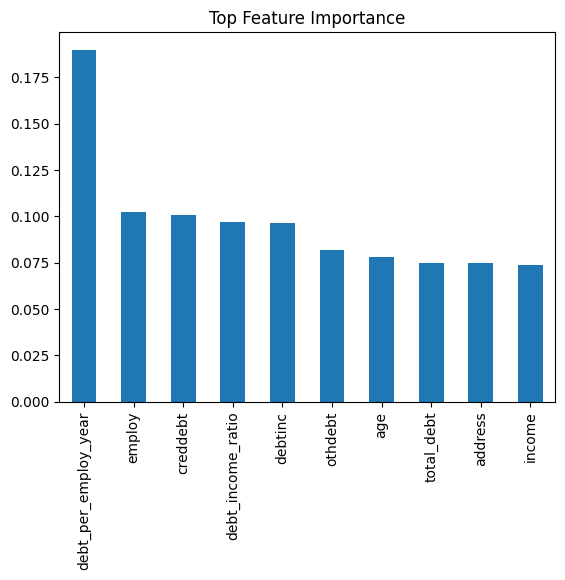

In [11]:
importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Feature Importance")
plt.show()

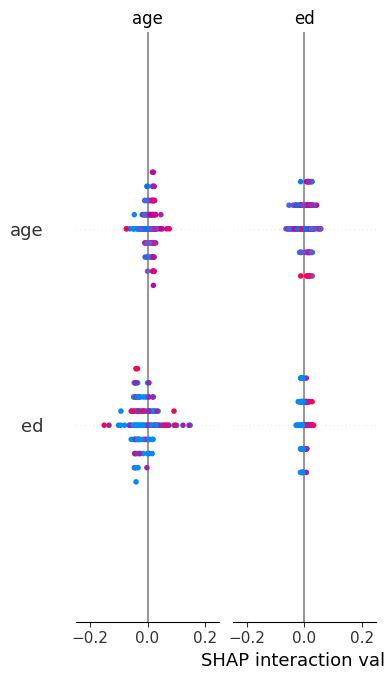

In [12]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [15]:
# Compare accuracy across gender

if 'gender' in df.columns:
    for group in df['gender'].unique():
        idx = df['gender'] == group
        acc = accuracy_score(y_test[idx], y_pred[idx])
        print(f"Accuracy for {group}: {acc}")
print('gender' in df.columns)

False
